\
# Generating stochastic Duffing trajectories with a conditional diffusion model

This notebook demonstrates the core workflow of `diffusionsde`:

1. Simulate an ensemble of trajectories of a **stochastically forced Duffing
   oscillator** (double-well potential, white and coloured noise);
2. Train a conditional denoising diffusion model (DDPM with DDIM sampling)
   on the simulated ensemble;
3. Generate new trajectories conditioned on held-out initial conditions;
4. Compare reference and generated ensembles in terms of sample paths,
   ensemble statistics, autocorrelation and the marginal distribution.

The Duffing oscillator is a canonical benchmark for generative models of
stochastic dynamical systems: it is nonlinear, multistable and noisy.

In [1]:
\
%matplotlib inline
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import TensorDataset

from diffusionsde import DDPM, DiffusionConfig, configure_matplotlib
from diffusionsde.evaluator import sample_acf
from diffusionsde.plotting import (
    ANALYTIC_COLOUR,
    GENERATED_COLOUR,
    REFERENCE_COLOUR,
    plot_acf_comparison,
    plot_marginal_distribution,
)

configure_matplotlib()

torch.manual_seed(42)
np.random.seed(42)

\
## 1. The stochastic Duffing oscillator

We simulate the three-variable stochastic differential equation

$$\begin{aligned}
\mathrm{d}q &= v\,\mathrm{d}t, \\
\mathrm{d}v &= \left(-\alpha q - \beta q^3 - \mu v + \gamma\cos(\Omega t) + \xi\right)\mathrm{d}t + \sqrt{2\mu\Theta}\,\mathrm{d}W_v, \\
\mathrm{d}\xi &= -\frac{\xi}{\tau}\,\mathrm{d}t + \sqrt{\frac{2D}{\tau}}\,\mathrm{d}W_\xi,
\end{aligned}$$

where $q$ is the displacement in the double-well potential ($\alpha < 0$,
$\beta > 0$), $v$ the velocity, $\gamma\cos(\Omega t)$ a periodic drive, and
$\xi$ an Ornstein-Uhlenbeck coloured-noise process. Integration uses the
stochastic Runge-Kutta method of strong order 1 (Heun's scheme).

In [2]:
\
@dataclass
class DuffingParams:
    alpha: float = -1.0   # linear stiffness (negative for double well)
    beta: float = 1.0     # nonlinear stiffness
    mu: float = 0.3       # damping
    gamma: float = 0.5    # forcing amplitude
    omega: float = 1.2    # forcing frequency
    theta: float = 0.05   # white-noise temperature on velocity
    D: float = 0.02       # coloured-noise intensity
    tau: float = 0.5      # coloured-noise correlation time

PARAMS = DuffingParams()
DT = 0.05
N_STEPS = 256


def _drift(state, t):
    q, v, xi = state
    return np.array([
        v,
        -PARAMS.alpha * q - PARAMS.beta * q**3 - PARAMS.mu * v
        + PARAMS.gamma * np.cos(PARAMS.omega * t) + xi,
        -xi / PARAMS.tau,
    ])


def _diffusion():
    return np.array([0.0, np.sqrt(2 * PARAMS.mu * PARAMS.theta),
                     np.sqrt(2 * PARAMS.D / PARAMS.tau)])


def simulate(q0, v0, seed=None):
    '''Integrate one trajectory with Heun's method (strong order 1).'''
    rng = np.random.default_rng(seed)
    state = np.array([q0, v0, 0.0])
    traj = np.empty(N_STEPS)
    g = _diffusion()
    sqrt_dt = np.sqrt(DT)
    for i in range(N_STEPS):
        traj[i] = state[0]
        f1 = _drift(state, i * DT)
        dW = rng.normal(size=3) * sqrt_dt
        f2 = _drift(state + f1 * DT + g * dW, (i + 1) * DT)
        state = state + 0.5 * (f1 + f2) * DT + g * dW
    return traj


def generate_ensemble(n_trajectories, seed=42):
    '''Ensemble with random initial conditions; returns (q0, trajectories).'''
    rng = np.random.default_rng(seed)
    q0s = rng.uniform(-1.8, 1.8, size=n_trajectories)
    v0s = rng.uniform(-1.0, 1.0, size=n_trajectories)
    trajectories = np.stack([
        simulate(q0, v0, seed=seed + k) for k, (q0, v0) in enumerate(zip(q0s, v0s))
    ])
    return q0s.astype(np.float32), trajectories.astype(np.float32)


q0_train, data_train = generate_ensemble(n_trajectories=512, seed=42)
q0_test, data_test = generate_ensemble(n_trajectories=128, seed=10_000)
print(f"Training ensemble: {data_train.shape}, test ensemble: {data_test.shape}")

Training ensemble: (512, 256), test ensemble: (128, 256)


\
A subset of the simulated training ensemble:

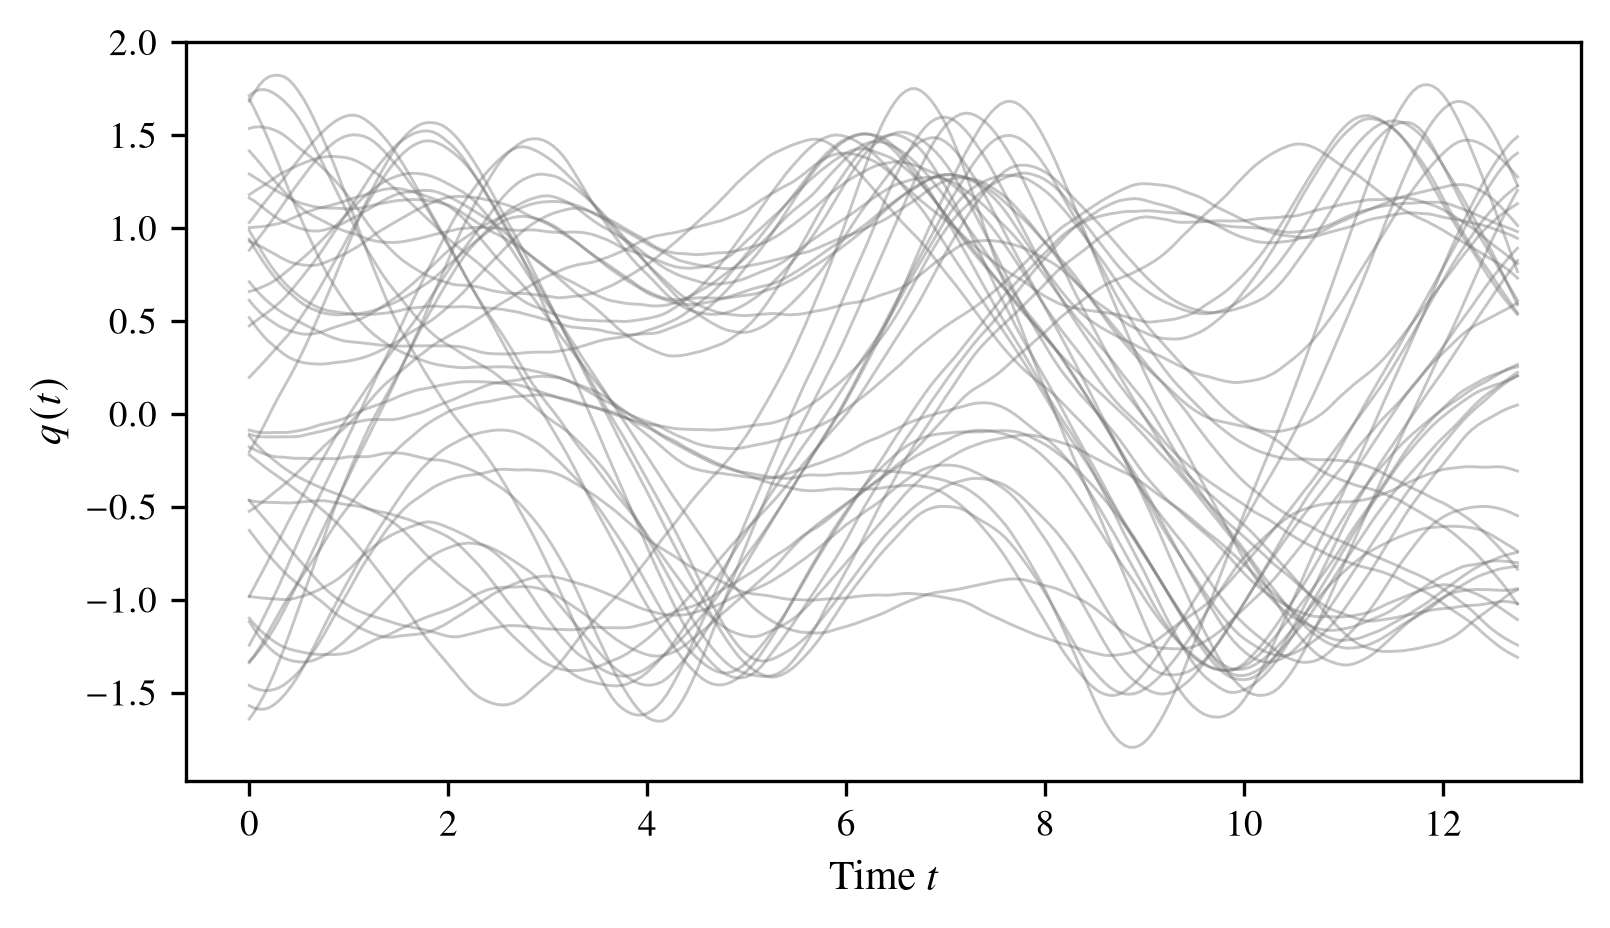

In [3]:
\
t = np.arange(N_STEPS) * DT

fig, ax = plt.subplots(figsize=(6, 3.2))
for trajectory in data_train[:40]:
    ax.plot(t, trajectory, color=REFERENCE_COLOUR, lw=0.7, alpha=0.4)
ax.set_xlabel(r"Time $t$")
ax.set_ylabel(r"$q(t)$")
plt.show()

\
## 2. Training the conditional diffusion model

Each trajectory is paired with a conditioning vector that encodes its initial
displacement $q_0$ in the first entry and is zero-padded to the trajectory
length. The model therefore learns the conditional distribution
$p(q(t)\,|\,q_0)$ over the full ensemble.

Trajectories are z-scored with the global training mean and standard
deviation; the same statistics scale the conditioning values.

In [4]:
\
TRAJECTORY_LENGTH = N_STEPS

data_mean = float(data_train.mean())
data_std = float(data_train.std())

def make_dataset(q0s, trajectories):
    x = (trajectories - data_mean) / data_std
    c = np.zeros((len(q0s), TRAJECTORY_LENGTH), dtype=np.float32)
    c[:, 0] = (q0s - data_mean) / data_std
    return TensorDataset(torch.tensor(x), torch.tensor(c))

train_ds = make_dataset(q0_train, data_train)

config = DiffusionConfig(
    n_timesteps=1000,
    trajectory_length=TRAJECTORY_LENGTH,
    batch_size=64,
    learning_rate=2e-4,
    n_epochs=150,
    hidden_dim=96,
    n_layers=3,
    n_conditioning_channels=1,
    n_output_channels=1,
)

ddpm = DDPM(config, sampler_type="ddim", sampler_kwargs={"num_inference_steps": 200})
metrics = ddpm.fit(train_ds)

Training DDPM on mps...
Model parameters: 3,082,913


Epoch 1/150:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/150:   0%|          | 0/8 [00:00<?, ?it/s, train_loss=0.907]

Epoch 1/150:  12%|█▎        | 1/8 [00:00<00:03,  2.20it/s, train_loss=0.907]

Epoch 1/150:  12%|█▎        | 1/8 [00:00<00:03,  2.20it/s, train_loss=0.443]

...

Epoch 150/150:  75%|███████▌  | 6/8 [00:00<00:00, 18.36it/s, train_loss=0.0201]

Epoch 150/150:  75%|███████▌  | 6/8 [00:00<00:00, 18.36it/s, train_loss=0.0278]

Epoch 150/150: 100%|██████████| 8/8 [00:00<00:00, 18.22it/s, train_loss=0.0278]

Epoch 150/150: 100%|██████████| 8/8 [00:00<00:00, 18.16it/s, train_loss=0.0278]

Epoch 150: Train Loss = 0.0196
Checkpoint saved to checkpoints/256_timesteps/checkpoint_epoch_150.pt


\
The training loss decreases steadily as the model learns to denoise the
Duffing trajectories at increasing noise levels:

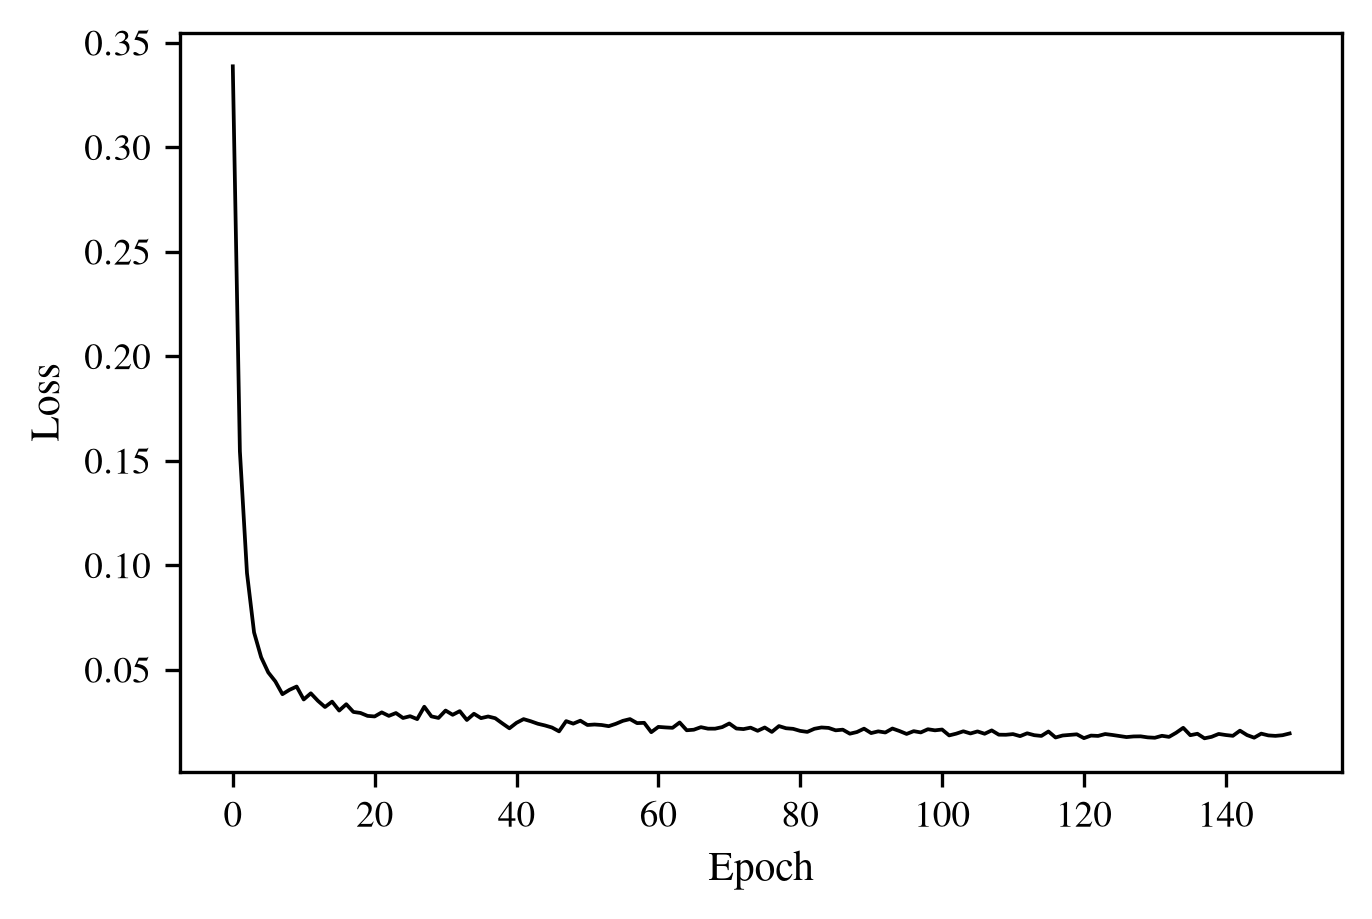

In [5]:
\
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(metrics["train_loss"], color=ANALYTIC_COLOUR, lw=0.9)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
plt.show()

\
## 3. Generating new trajectories

We condition on the **held-out** initial displacements — initial conditions
never seen during training — and average nothing: every generated trajectory
is one draw from the learned conditional distribution.

In [6]:
\
ddpm.freeze()

conditioning = torch.zeros(len(q0_test), TRAJECTORY_LENGTH)
conditioning[:, 0] = torch.tensor((q0_test - data_mean) / data_std)

generated = []
with torch.no_grad():
    for start in range(0, len(conditioning), config.batch_size):
        batch = conditioning[start : start + config.batch_size].to(config.device)
        samples = ddpm.generate(batch, n_samples=1, show_progress=False)
        generated.append(samples.squeeze(1).cpu())

generated = torch.cat(generated).numpy() * data_std + data_mean
print(f"Generated ensemble: {generated.shape}")

Generated ensemble: (128, 256)


\
## 4. Reference versus generated ensembles

Sample paths from both ensembles side by side (top), and the ensemble mean
$\pm$ one standard deviation (bottom):

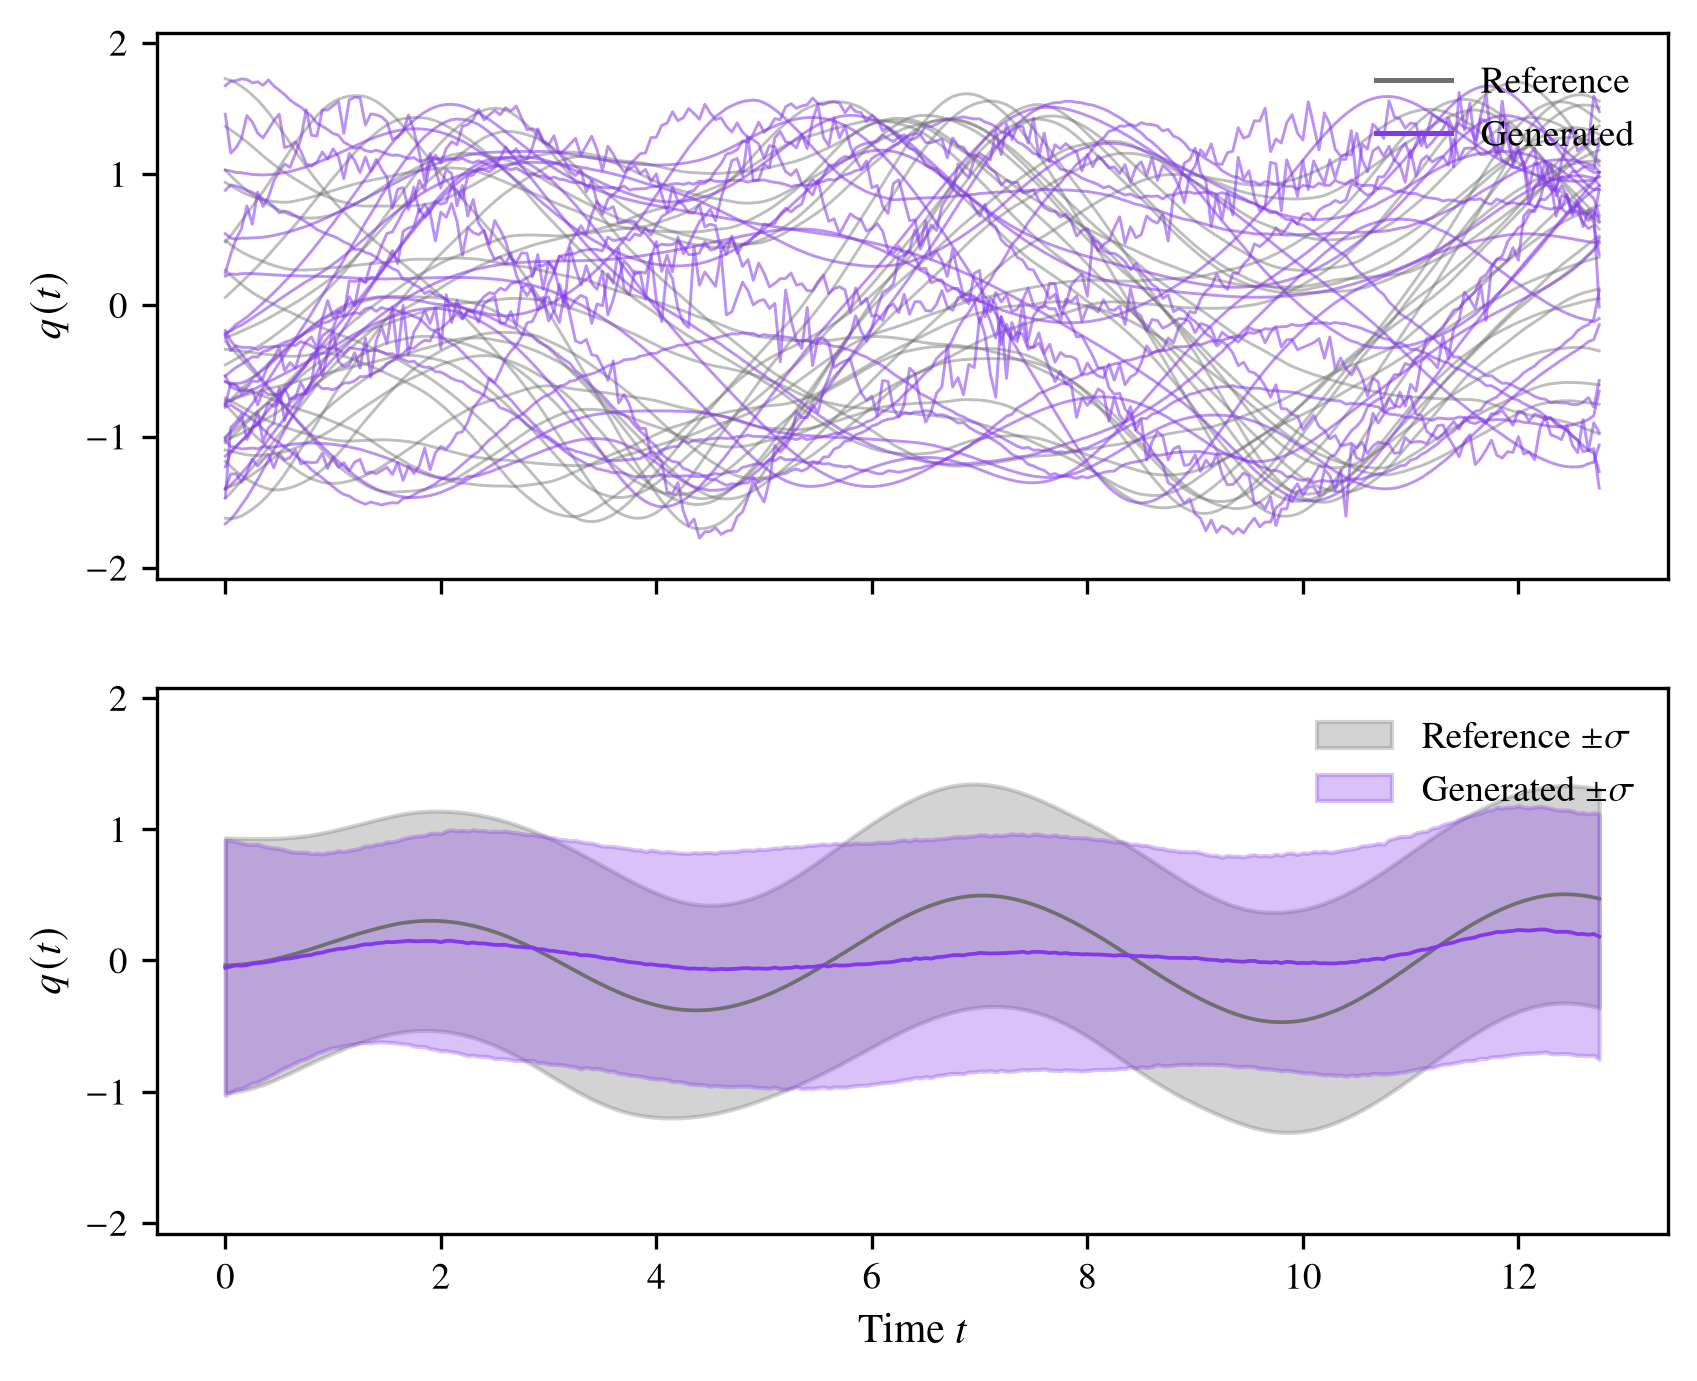

In [7]:
\
fig, (ax_paths, ax_stats) = plt.subplots(2, 1, figsize=(6.5, 5.2), sharex=True)

# Limit the vertical range to the reference ensemble so rare boundary
# artefacts of the sampler do not dictate the axis scale.
q_lo, q_hi = np.percentile(data_test, [0.5, 99.5])
pad = 0.15 * (q_hi - q_lo)

for trajectory in data_test[:25]:
    ax_paths.plot(t, trajectory, color=REFERENCE_COLOUR, lw=0.7, alpha=0.45)
for trajectory in generated[:25]:
    ax_paths.plot(t, trajectory, color=GENERATED_COLOUR, lw=0.7, alpha=0.55)
ax_paths.plot([], [], color=REFERENCE_COLOUR, lw=1.2, label="Reference")
ax_paths.plot([], [], color=GENERATED_COLOUR, lw=1.2, label="Generated")
ax_paths.set_ylabel(r"$q(t)$")
ax_paths.set_ylim(q_lo - pad, q_hi + pad)
ax_paths.legend(frameon=False, loc="upper right")

mean_ref, std_ref = data_test.mean(axis=0), data_test.std(axis=0)
mean_gen, std_gen = generated.mean(axis=0), generated.std(axis=0)
ax_stats.fill_between(t, mean_ref - std_ref, mean_ref + std_ref,
                      color=REFERENCE_COLOUR, alpha=0.30, label=r"Reference $\pm\sigma$")
ax_stats.fill_between(t, mean_gen - std_gen, mean_gen + std_gen,
                      color=GENERATED_COLOUR, alpha=0.30, label=r"Generated $\pm\sigma$")
ax_stats.plot(t, mean_ref, color=REFERENCE_COLOUR, lw=0.9)
ax_stats.plot(t, mean_gen, color=GENERATED_COLOUR, lw=0.9)
ax_stats.set_xlabel(r"Time $t$")
ax_stats.set_ylabel(r"$q(t)$")
ax_stats.set_ylim(q_lo - pad, q_hi + pad)
ax_stats.legend(frameon=False, loc="upper right")

fig.align_ylabels()
plt.show()

\
Beyond visual inspection, `diffusionsde` ships statistical evaluators. The
autocorrelation function quantifies temporal structure, and the pooled
marginal histogram compares the invariant distribution of the double-well
system:

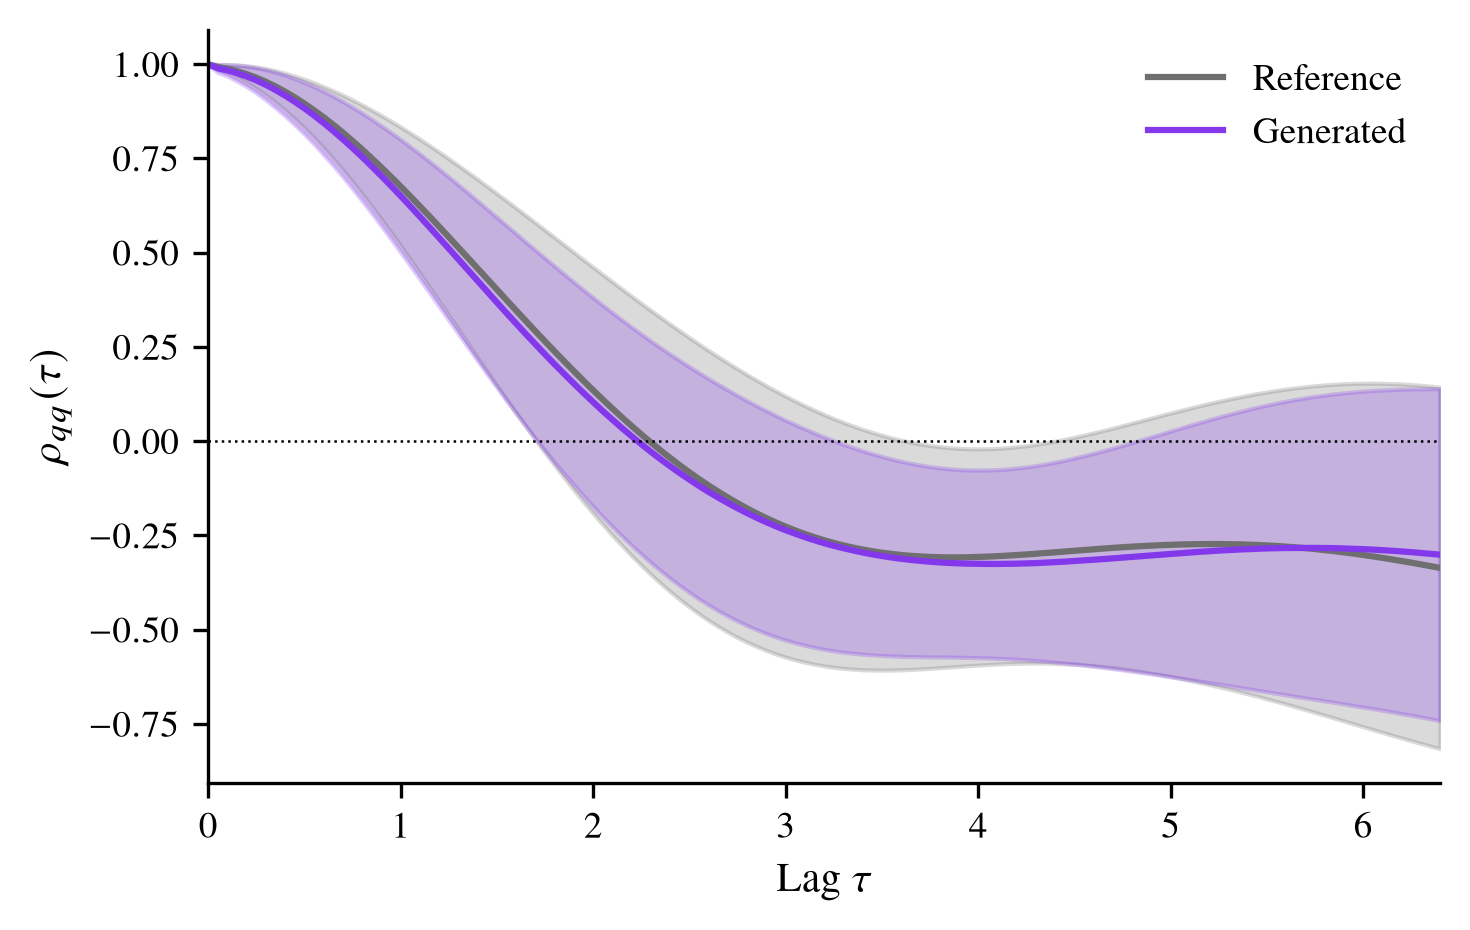

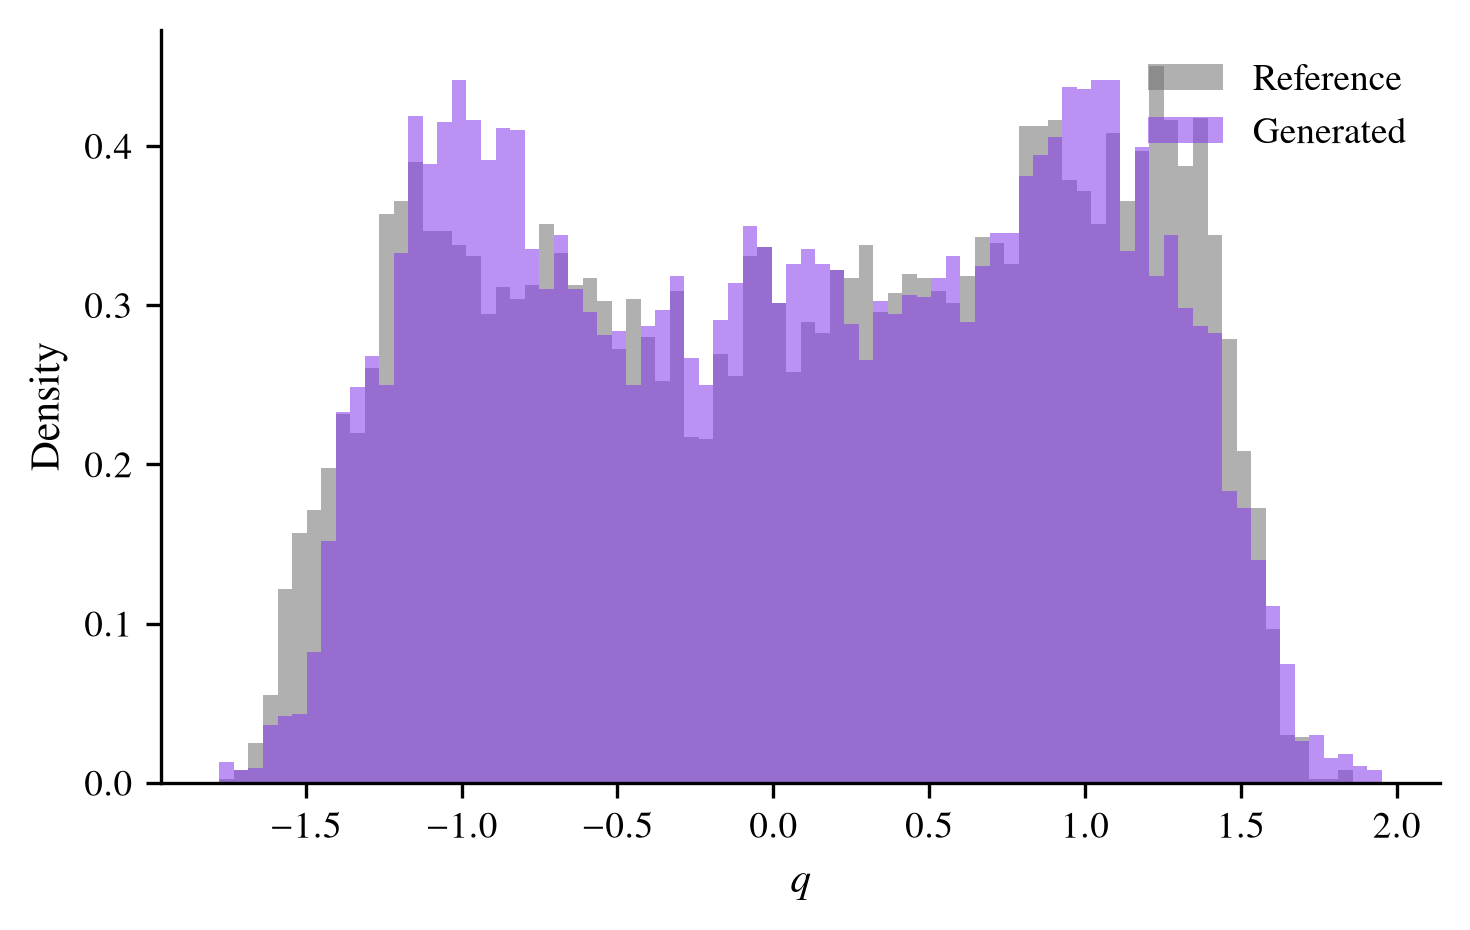

In [8]:
\
MAX_LAG = 128

acf_ref = sample_acf(torch.tensor(data_test), max_lag=MAX_LAG)
acf_gen = sample_acf(torch.tensor(generated), max_lag=MAX_LAG)
lag_axis = np.arange(MAX_LAG + 1) * DT

plot_acf_comparison(
    acf_ref.mean(dim=0).numpy(), acf_gen.mean(dim=0).numpy(), lag_axis,
    real_acf_std=acf_ref.std(dim=0).numpy(),
    generated_acf_std=acf_gen.std(dim=0).numpy(),
    xlabel=r"Lag $\tau$",
    ylabel=r"$\rho_{qq}(\tau)$",
)
plot_marginal_distribution(data_test, generated, xlabel=r"$q$", tail_fraction=0.5)
plt.show()

\
The generated ensemble reproduces the two-well invariant distribution and
the oscillatory autocorrelation imposed by the periodic drive. Individual
sample paths are statistically faithful; note, however, that the ensemble
mean of the generated data partially averages out the phase-coherent
response to the deterministic drive that is visible in the reference mean —
a known effect when the conditioning does not encode drive phase.

## Where to go next

- **Multi-channel conditioning**: set `n_conditioning_channels > 1` to
  condition on several physical parameters (e.g. $q_0$, $v_0$, $\gamma$ as in
  the bundled Duffing study).
- **Multivariate series**: `n_output_channels > 1` generates $(q, v)$ jointly.
- **Inverse problems**: `InverseProblem` infers the conditioning parameters
  that produce an observed trajectory.